# Reconstruct the Stanford Bunny

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
# from torch import nn
# from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
import time
import copy
import trimesh
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import GeneralNet
from training.modular.optimizers import GaussNewton
from util.visualization.utils_mesh import get_mesh
from training.modular.residuals import ResidualLibrary, ResidualTerm, compute_loss


torch.manual_seed(0)


device = 'cpu' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [2]:
mesh = trimesh.load("bun_zipper.ply")
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(mesh.vertices, mesh.faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_sub.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

/opt/homebrew/Caskroom/miniforge/base/envs/ginns/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ginns/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int64" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [3]:
pts = torch.tensor(mesh.vertices, dtype=torch.float64)
true_normals = torch.tensor(mesh.vertex_normals, dtype=torch.float64)

# Normalize
center = pts.mean(dim=0)
pts -= center

scale = pts.norm(dim=1).max()
pts /= scale

# Train on fraction of data or full data
# subsample_fraction = 0.2
subsample_fraction = 1.0
num_points = pts.shape[0]

# Randomly shuffle the points
indices = torch.randperm(num_points)
num_subsampled = int(subsample_fraction * num_points)
subsampled_indices = indices[:num_subsampled]
pts_sub = pts[subsampled_indices]
true_normals_sub = true_normals[subsampled_indices]


## Pretraining

In [4]:
model = GeneralNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
model = model.double()
torch.compile(model)
# bind_model(model)

# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1.5, 1.5], [-1.5, 1.5], [-1.5, 1.5]], dtype=torch.float64)
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]

# SDF of a unit ball
def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)
    targets = inputs.norm(dim=1) - 1  # SDF of unit ball
    preds = model(inputs).squeeze(1)
    return 0.5 * (preds - targets).square().mean()

# Pretraining loop
pretrain_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss = {loss.item():.6f}")

print("Pretraining completed!")


Pretrain Iter 0: Loss = 0.163808
Pretrain Iter 100: Loss = 0.054542
Pretrain Iter 200: Loss = 0.000885
Pretrain Iter 300: Loss = 0.000668
Pretrain Iter 400: Loss = 0.000575
Pretrain Iter 500: Loss = 0.000478
Pretrain Iter 600: Loss = 0.000413
Pretrain Iter 700: Loss = 0.000366
Pretrain Iter 800: Loss = 0.000331
Pretrain Iter 900: Loss = 0.000307
Pretraining completed!


In [5]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

/opt/homebrew/Caskroom/miniforge/base/envs/ginns/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

GeneralNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [6]:
# Loss weights:
loss_weights = {"data": 1.0, "eikonal": 0.01, "normal": 1.0}
# loss_weights = {"data": 1.0, "eikonal": 0.1, "normal": 1.0}



# pts_eikonal = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
min_vals = pts.min(dim=0).values-0.2  # min along each axis (x, y, z)
max_vals = pts.max(dim=0).values+0.2
# pts_eikonal = torch.rand([4000, 3], dtype=torch.float64)
pts_eikonal = torch.rand([5000, 3], dtype=torch.float64)
pts_eikonal = pts_eikonal * (max_vals - min_vals) + min_vals
# n_per_dim = int(round(4000 ** (1/3)))  # ~16 to get ~4096 points total

# x = torch.linspace(min_vals[0], max_vals[0], steps=n_per_dim, dtype=torch.float64)
# y = torch.linspace(min_vals[1], max_vals[1], steps=n_per_dim, dtype=torch.float64)
# z = torch.linspace(min_vals[2], max_vals[2], steps=n_per_dim, dtype=torch.float64)

# X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
# pts_eikonal = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3)

# pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
# pts_surface = pts

config = {
    "pts_data": pts_sub,
    # "pts_boundary": pts_sub,
    "pts_eikonal": pts_eikonal,
    "pts_surface": pts_sub,
    "true_normals": true_normals_sub,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
    # "regularization": 1e-8,
    
}

# model = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
# model.double()

In [6]:
res_lib = ResidualLibrary(model)

min_vals = pts.min(dim=0).values-0.2  # min along each axis (x, y, z)
max_vals = pts.max(dim=0).values+0.2
pts_eikonal = torch.rand([5000, 3], dtype=torch.float64)
pts_eikonal = pts_eikonal * (max_vals - min_vals) + min_vals

## Select the residual terms defining the specific problem
## (incl. weight, points, and (optional) target values)
res_terms = {
    "data":
        ResidualTerm(res_lib._data,           1.0,  pts_sub, vals=0),
    "eikonal":
        ResidualTerm(res_lib._eikonal,        1e-2, pts_eikonal,        ),
    "normal":
        ResidualTerm(res_lib._normal,         1.0,  pts_sub, true_normals_sub),
}

In [7]:
model = model.double()
params = model.params
loss_over_time = {}
best_loss = float('inf')

optim = GaussNewton(model, res_terms, lr=1e-1, regularization=1e-6, do_line_search=True)
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=28000)
start_time = time.time()
current_time = 0

for i in (pbar:=trange(100000)):
    # if current_time > 1200:
    if current_time > 600: # Shorter run for testing
        break
    optim.zero_grad()
    
    ## Evaluate the losses
    loss, unweighted_losses = compute_loss(params, res_terms, return_unweighted_losses=True)
        
    loss.backward()
    
    with torch.no_grad():
        loss_metric = unweighted_losses["data"] + unweighted_losses["normal"]

        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()
        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())

        unweighted_losses_str = " ".join(f"{key}: {l.item():.2e}" for key, l in unweighted_losses.items())
        pbar.set_description(unweighted_losses_str + " "
                            f"nof_pts: {len(pts_sub)}"
                            )
    optim.step()

# Optional: Load the best model after training
# if best_model_state is not None:
#     model.load_state_dict(best_model_state)
#     print(f"Best model loaded with loss {best_loss}")

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

  0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
model = model.double()
params = model.params
loss_over_time = {}

optim = torch.optim.LBFGS(model.parameters(), lr=1e-1, max_iter=20, history_size=10)
start_time = time.time()
current_time = 0
best_loss = float('inf')
best_model_state = None

pbar = trange(100000)
for i in pbar:
    if current_time > 600:
        break

    def closure():
        optim.zero_grad()
        loss, _ = compute_loss(params, res_terms, return_unweighted_losses=True)
        loss.backward()
        return loss

    loss, unweighted_losses = compute_loss(params, res_terms, return_unweighted_losses=True)
    optim.step(closure)

    with torch.no_grad():
        loss_metric = unweighted_losses["data"] + unweighted_losses["normal"]
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()

        if loss_metric.item() < best_loss:
            best_loss = loss_metric.item()
            best_model_state = copy.deepcopy(model.state_dict())

        unweighted_losses_str = " ".join(f"{key}: {l.item():.2e}" for key, l in unweighted_losses.items())
        pbar.set_description(unweighted_losses_str + " "
                            f"nof_pts: {len(pts_sub)}"
                            )

# Optional: Load the best model after training
# if best_model_state is not None:
#     model.load_state_dict(best_model_state)
#     print(f"Best model loaded with loss {best_loss}")

plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

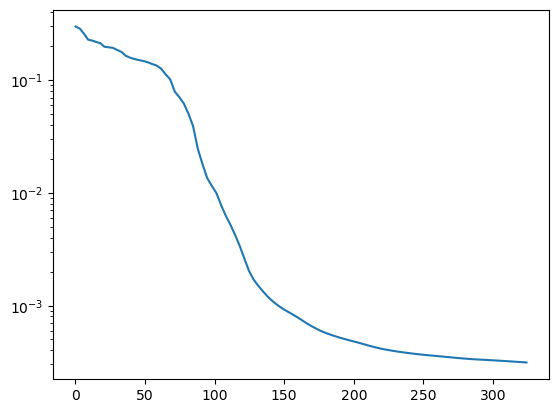

In [8]:
plt.plot(loss_over_time.keys(), loss_over_time.values())
plt.semilogy()
plt.show()

In [9]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=pts.min(dim=0).values-0.01,
    bbox_max=pts.max(dim=0).values+0.15,
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

GeneralNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [10]:
# torch.save(model.state_dict(), '3,32,32,32,1,sin,bunny,gn_old')

In [11]:
# os.makedirs("Data Bunny", exist_ok=True)

# loss_file = os.path.join("Data Bunny", "loss_over_time_bunny_gn.pth")

# torch.save(loss_over_time, loss_file)
# print(f"Loss saved to {loss_file}")